In [42]:
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library(circlize)
library(tibble)


In [54]:
path<-'/mnt/cold1/snaketree/prj/scRNA/dataset/Graph_NN/notebook/bbknn_NT_KRAS/npcs=20__nwb=3__trim=None__res=0.3/markers_leiden_r0.3_FULL/gsea_sign_once_KEGG.csv'
data<-read.table(path,header = TRUE,stringsAsFactors = FALSE,sep=',')

pdf 
  2

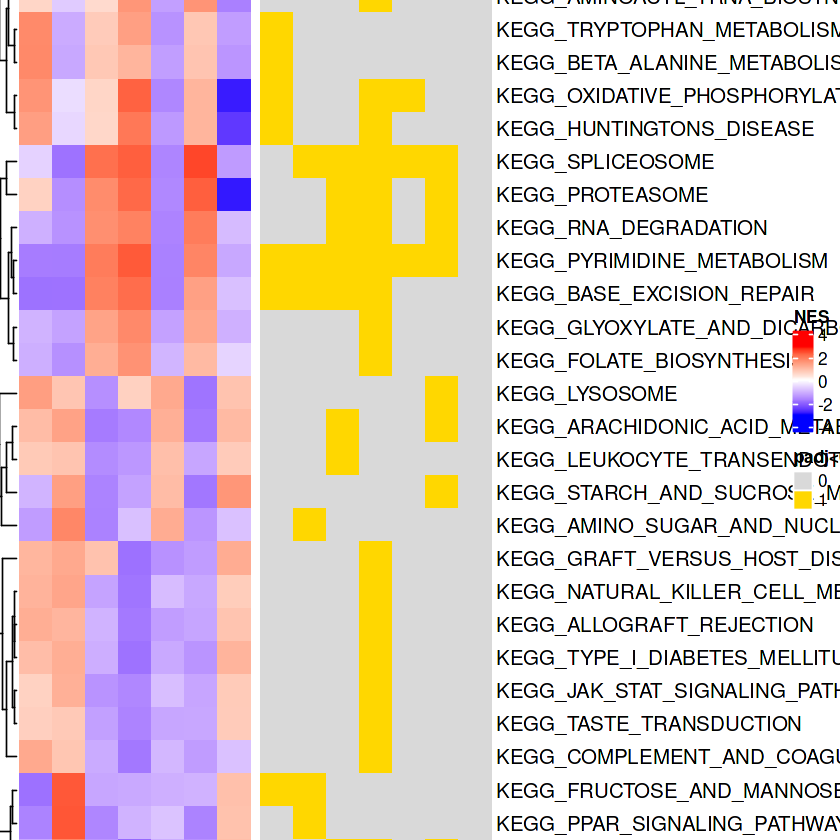

In [55]:
alpha <- 0.05 
gsea_only<-data

x <- gsea_only %>%
  mutate(cluster = factor(cluster, levels = 0:6)) %>%
  group_by(ID, cluster) %>%
  summarise(NES = first(NES), p.adjust = first(p.adjust), .groups = "drop")


nes_mat <- x %>%
  select(ID, cluster, NES) %>%
  pivot_wider(names_from = cluster, values_from = NES) %>%
  column_to_rownames("ID") %>%
  as.matrix()

padj_mat <- x %>%
  select(ID, cluster, p.adjust) %>%
  pivot_wider(names_from = cluster, values_from = p.adjust) %>%
  column_to_rownames("ID") %>%
  as.matrix()


sig_mat <- ifelse(padj_mat < alpha, 1, 0)
sig_mat[is.na(sig_mat)] <- 0


lim <- max(abs(nes_mat), na.rm = TRUE)
col_nes <- colorRamp2(c(-lim, 0, lim), c("blue", "white", "red"))
col_sig <- c("0" = "grey85", "1" = "gold")
cell_w <- 7 
cell_h <- 7


h_nes <- Heatmap(
  nes_mat, name = "NES", col = col_nes, na_col = "grey95",
  cluster_rows = TRUE, cluster_columns = FALSE,
    width  = unit(cell_w * ncol(nes_mat), "mm"),
  height = unit(cell_h * nrow(nes_mat), "mm"),
  show_row_names = TRUE, show_column_names = TRUE
)

h_sig <- Heatmap(
  sig_mat, name = paste0("padj<", alpha),
  col = col_sig, na_col = "grey95",
    width  = unit(cell_w * ncol(nes_mat), "mm"),
  height = unit(cell_h * nrow(nes_mat), "mm"),
  cluster_rows = FALSE, cluster_columns = FALSE,  
  show_row_names = TRUE, show_column_names = TRUE
)

ht <- h_nes + h_sig


out <- '/mnt/cold1/snaketree/prj/scRNA/dataset/Graph_NN/notebook/bbknn_NT_KRAS/npcs=20__nwb=3__trim=None__res=0.3/markers_leiden_r0.3_FULL/gsea_sign_once_KEGG.pdf'


nr <- nrow(nes_mat)
nc <- ncol(nes_mat) + ncol(sig_mat)

pdf(out, width = 10 + 0.4*nc, height = 10 + 0.18*nr, useDingbats = FALSE)
draw(ht, heatmap_legend_side = "left", annotation_legend_side = "lef")
dev.off()
draw(ht, heatmap_legend_side = "right")

